<h1>Assignment 4: <strong> CNN for Image Classification</strong></h1>
Name : Sammit Poudyal <br/>
Class : CE 2022<br/>
Registration Number : 032329-22<br>
Date : 26/04/2026<br/>
Dataset Used :<strong> Intel Image Classification </strong><br/>


## 1. Objective


The goal of this assignment is to design, train, and evaluate a Convolutional Neural Network (CNN) for a multi-class image classification task.  The Intel Image Classification dataset. will be used , which contains images of natural scenes divided into six categories.

The goals of this assignment are as follows:
- To understand class distribution and visual patterns (Data Exploration)
- To implement processing which includes data augmentation and normalization.
- To build architectures, a custom CNN and compare it against a standard Multi-Layer Perceptron (MLP).
- To train both models and monitor performance.
- To analyze the results using accuracy, loss curves, and confusion matrices.

## 2. Theoretical Background


### 2.1 Multilayer Perceptrons (MLP) and CNNs
- MLP(Multi-Layer Perceptron): A (MLP) is a type of artificial neural network consisting of multiple layers of neurons. The neurons in the MLP typically use nonlinear activation functions, allowing the network to learn complex patterns in data. MLPs are significant in machine learning because they can learn nonlinear relationships in data, making them powerful models for tasks such as classification, regression, and pattern recognition.
- CNN (Convolutional Neural Network): CNNs are designed to effectively process grid-like data, such as images. They consist of layers of convolutional filters that learn hierarchical representations of features within the input data. CNNs are widely used in tasks like image classification, object detection, and image segmentation.

### 2.2 The Convolution Operation
The core building block of a CNN is the convolutional layer. It operates by sliding a small matrix of learnable weights, called a **filter** or **kernel**, across the input image. At each position, an element-wise dot product is computed between the filter and the corresponding input patch, producing a 2D activation map (feature map).
- **Formula for Output Spatial Dimension:** Given an input size $W$, filter size $K$, padding $P$, and stride $S$, the output dimension $O$ is calculated as:
  $$O = \frac{W - K + 2P}{S} + 1$$
- **Padding:** Adding pixels (usually zeros) to the border of the input to control the spatial size of the output feature maps.
- **Stride:** The step size by which the filter moves across the image.

### 2.3 Pooling and Spatial Invariance
Pooling layer is used in CNNs to reduce the spatial dimensions (width and height) of the input feature maps while retaining the most important information. It involves sliding a two-dimensional filter over each channel of a feature map and summarizing the features within the region covered by the filter.
- Max Pooling: Max pooling selects the maximum element from the region of the feature map covered by the filter. Thus, the output after max-pooling layer would be a feature map containing the most prominent features of the previous feature map. 
Max pooling layer preserves the most important features (edges, textures, etc.) and provides better performance in most cases.
- Translation Invariance: Pooling makes the network slightly invariant to small shifts and distortions. Translation invariance refers to a situation where a change in position of an object does not affect the nature of the output.

### 2.4 Activation Functions
- ReLU (Rectified Linear Unit): The Rectified Linear Unit is the most commonly used activation function in deep learning models. The function returns 0 if it receives any negative input, but for any positive value  x, it returns that value back, allowing it to learn complex, non-linear mappings. The function is defined as $f(x) = \max(0, x)$. This helps to mitigate the vanishing gradient problem and accelerates the convergence compared to older functions like Sigmoid or Tanh.
- Batch Normalization (BatchNorm) : BatchNorm is a technique to accelerate deep neural network training and improve stability by re-centering and re-scaling layer inputs, mitigating internal covariate shift. It normalizes activations for each mini-batch to a mean of zero and standard deviation of one, using learnable parameters to maintain model representation capacity. 


### 2.5 Regularization to Prevent Overfitting
Image classification networks are highly susceptible to overfitting, where the model memorizes the training data but fails to generalize. Two key techniques used in this implementation are:
- Data Augmentation: This is a technique to increase the diversity of your training set by applying random (but realistic) transformations, such as image rotation. It is basically generating new training examples from existing ones through various transformations. It is a very effective regularization tool and is widely used in all CV problems and models.
- Dropout: A regularization technique used in the dense layers where randomly selected neurons are ignored (or "dropped out") during each forward pass. This prevents neurons from co-adapting too strongly and forces the network to learn redundant, robust feature representations.

### 2.6 Loss Function and Optimization
- Categorical Cross-Entropy: The standard loss function for multi-class classification tasks. It measures the divergence between the true one-hot encoded labels and the model's predicted probability distribution.
- Optimization (Adam vs. SGD): The network uses optimizers to update the weights based on the computed gradients. While Stochastic Gradient Descent (SGD) with momentum is highly effective if tuned carefully, adaptive optimizers like Adam (Adaptive Moment Estimation) dynamically adjust the learning rate for each parameter, generally leading to faster convergence out of the box.

## 3. Dataset Description
Name: Intel Image Classification  
Source: Kaggle **(puneet6060/intel-image-classification)** <br>
Samples: Natural scene images divided into training, validation, and testing sets.  
- Train: 11,227 images
- Validation: 2,807 images
- Test: 3,000 images  
Classes: 6 categories (buildings, forest, glacier, mountain, sea, street). 
Format: RGB color images resized to 128×128 pixels for this implementation.  
Normalization: Standard ImageNet normalization is applied with (Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]).

## 4. Implementation

### 4.1 Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix, classification_report

# Settings
RANDOM_SEED = 61
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15
IMG_SIZE = 128
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Running on device: {DEVICE}")

print(torch.backends.mps.is_available())   # Should be True
print(torch.backends.mps.is_built())       # Should be True

# Reproducibility
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True

Running on device: mps
True
True


### 4.2 Dataset Loading and Preprocessing

In [2]:
import kagglehub
from pathlib import Path

#downloading dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

/Users/sammit/Desktop/learn/NeuralNetwork-DeepLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/sammit/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [3]:
# ─── PATH RESOLUTION ────────────────────────────────────────────────────────
# The path variable is inherited from the previous cell (kagglehub)
from pathlib import Path
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

BASE_DIR = Path(path)


train_nested = BASE_DIR / "seg_train" / "seg_train"
train_flat   = BASE_DIR / "seg_train"

test_nested = BASE_DIR / "seg_test" / "seg_test"
test_flat   = BASE_DIR / "seg_test"

# Assigning the correct path
if train_nested.exists() and train_nested.is_dir():
    TRAIN_DIR = train_nested
elif train_flat.exists() and train_flat.is_dir():
    TRAIN_DIR = train_flat
else:
    raise FileNotFoundError(f"Could not find training data in {BASE_DIR}")

if test_nested.exists() and test_nested.is_dir():
    TEST_DIR = test_nested
elif test_flat.exists() and test_flat.is_dir():
    TEST_DIR = test_flat
else:
    raise FileNotFoundError(f"Could not find test data in {BASE_DIR}")

print(f"Using Train Dir: {TRAIN_DIR}")
print(f"Using Test Dir:  {TEST_DIR}")

# Apply augmentation (flips, rotation) only to the training set to prevent overfitting.
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    # FIX: Standard rotation. The black corners it creates are normal and harmless!
    transforms.RandomRotation(15), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test/Validation transforms should NEVER have random augmentations
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#load datasets
base_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
base_val_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=test_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)

# Calculatting the split sizes (80/20 split)
train_size = int(0.8 * len(base_train_dataset))
val_size = len(base_train_dataset) - train_size

# Generate random indices for the split
indices = torch.randperm(len(base_train_dataset), generator=torch.Generator().manual_seed(RANDOM_SEED)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Use Subset to apply the indices to the correctly transformed datasets
train_dataset = Subset(base_train_dataset, train_indices)
val_dataset = Subset(base_val_dataset, val_indices)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Extract class names from the base dataset
class_names = base_train_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Using Train Dir: /Users/sammit/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train
Using Test Dir:  /Users/sammit/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test/seg_test
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train samples: 11227, Val samples: 2807, Test samples: 3000


### 4.3 Dataset Visualisation

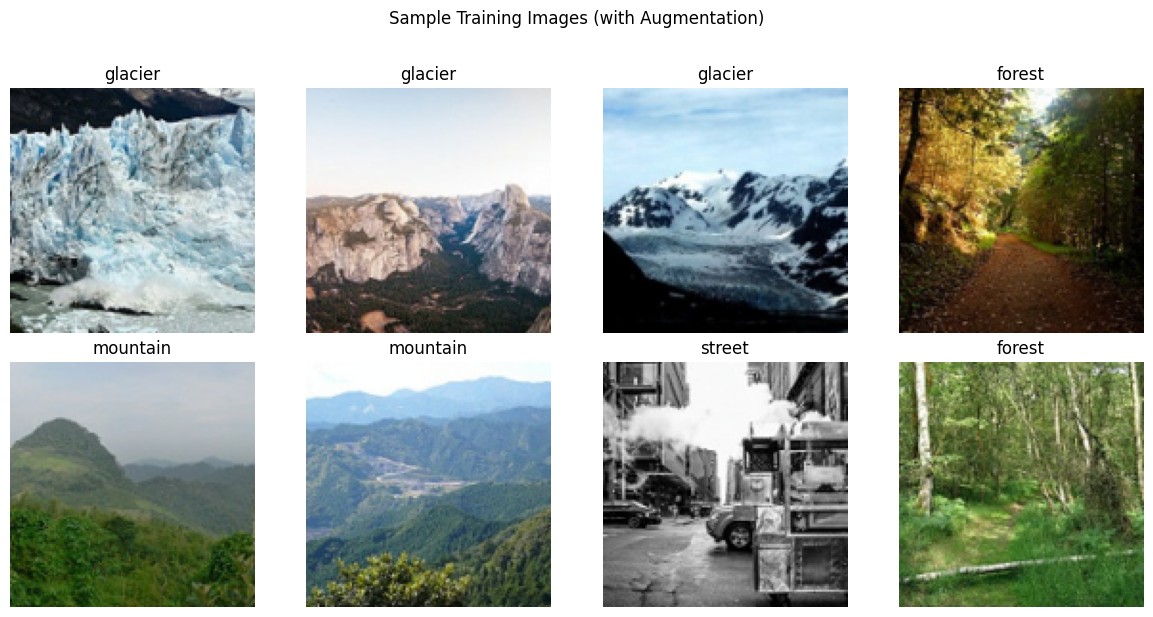

In [4]:
def imshow(img, title=None):
    #Utility funcn to display an image from a tensor.
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Getting a batch of training data
# Change train_loader to val_loader (or test_loader)
dataiter = iter(val_loader) 
images, labels = next(dataiter)

# Plot the first 8 images
fig = plt.figure(figsize=(12, 6))
for idx in np.arange(8):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    imshow(images[idx], title=class_names[labels[idx]])
plt.suptitle("Sample Training Images (with Augmentation)", y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Model Architecture

In [5]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(BaselineMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        
        # Block 1: Input (3, 128, 128) to (32, 64, 64)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 2: (32, 64, 64) to (64, 32, 32)
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 3: (64, 32, 32) to (128, 16, 16)
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 4: (128, 16, 16) to (256, 8, 8)
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Classifier
        # After 4 pooling layers: 128 -> 64 -> 32 -> 16 -> 8
        self.fc = nn.Linear(256 * 8 * 8, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

# Initializing models
input_dim = 3 * IMG_SIZE * IMG_SIZE
mlp_model = BaselineMLP(input_dim, num_classes).to(DEVICE)
cnn_model = CustomCNN(num_classes).to(DEVICE)

print("MLP Parameters:", sum(p.numel() for p in mlp_model.parameters()))
print("CNN Parameters:", sum(p.numel() for p in cnn_model.parameters()))


MLP Parameters: 25299206
CNN Parameters: 487686


### 4.5 Training and Evalaution Utilities

In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

## 5.Experiments

### 5.1 Training Baseline MLP 

In [7]:
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=LEARNING_RATE)
history_mlp = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("--- Starting Training: Baseline MLP ---")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(mlp_model, train_loader, optimizer_mlp, DEVICE)
    val_loss, val_acc = validate(mlp_model, val_loader, DEVICE)
    
    history_mlp['train_loss'].append(train_loss)
    history_mlp['val_loss'].append(val_loss)
    history_mlp['train_acc'].append(train_acc)
    history_mlp['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


--- Starting Training: Baseline MLP ---


Epoch 1/15 | Train Loss: 2.7730 | Val Loss: 1.3901 | Val Acc: 48.24%


Epoch 2/15 | Train Loss: 1.4940 | Val Loss: 1.3078 | Val Acc: 52.26%


Epoch 3/15 | Train Loss: 1.4325 | Val Loss: 1.2980 | Val Acc: 54.08%


Epoch 4/15 | Train Loss: 1.4014 | Val Loss: 1.2915 | Val Acc: 52.90%


...

Epoch 11/15 | Train Loss: 1.3444 | Val Loss: 1.2635 | Val Acc: 52.05%


Epoch 12/15 | Train Loss: 1.3726 | Val Loss: 1.2236 | Val Acc: 55.54%


Epoch 13/15 | Train Loss: 1.3602 | Val Loss: 1.3015 | Val Acc: 47.92%


Epoch 14/15 | Train Loss: 1.3493 | Val Loss: 1.2304 | Val Acc: 53.08%


Epoch 15/15 | Train Loss: 1.3623 | Val Loss: 1.2065 | Val Acc: 55.01%


### 5.2: Training Custom CNN


In [8]:
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
history_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("--- Starting Training: Custom CNN ---")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, optimizer_cnn, DEVICE)
    val_loss, val_acc = validate(cnn_model, val_loader, DEVICE)
    
    history_cnn['train_loss'].append(train_loss)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


--- Starting Training: Custom CNN ---


Epoch 1/15 | Train Loss: 1.4789 | Val Loss: 0.8981 | Val Acc: 70.97%


Epoch 2/15 | Train Loss: 0.8903 | Val Loss: 0.9904 | Val Acc: 70.89%


Epoch 3/15 | Train Loss: 0.7925 | Val Loss: 0.9144 | Val Acc: 74.28%


Epoch 4/15 | Train Loss: 0.6846 | Val Loss: 0.5557 | Val Acc: 81.40%


...

Epoch 11/15 | Train Loss: 0.4331 | Val Loss: 0.4517 | Val Acc: 84.40%


Epoch 12/15 | Train Loss: 0.3902 | Val Loss: 0.4026 | Val Acc: 86.43%


Epoch 13/15 | Train Loss: 0.4051 | Val Loss: 0.3876 | Val Acc: 86.68%


Epoch 14/15 | Train Loss: 0.3821 | Val Loss: 0.3997 | Val Acc: 86.25%


Epoch 15/15 | Train Loss: 0.3565 | Val Loss: 0.3836 | Val Acc: 86.32%


### 5.3 Pooling and Filter Experiments (CNN Ablation)

In [20]:
class AblationCNN(nn.Module):
    def __init__(self, num_classes, filters=(32, 64, 128), pool_type="max"):
        super().__init__()

        if pool_type not in {"max", "avg"}:
            raise ValueError("pool_type must be 'max' or 'avg'")

        def make_pool():
            return nn.MaxPool2d(2, 2) if pool_type == "max" else nn.AvgPool2d(2, 2)

        c1, c2, c3 = filters

        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(),
            make_pool(),
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(),
            make_pool(),
            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(),
            make_pool(),
        )

        reduced_size = IMG_SIZE // (2 ** 3)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3 * reduced_size * reduced_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


ablation_configs = [
    {"name": "MaxPool + Small Filters", "filters": (16, 32, 64), "pool_type": "max"},
    {"name": "MaxPool + Wider Filters", "filters": (32, 64, 128), "pool_type": "max"},
    {"name": "AvgPool + Wider Filters", "filters": (32, 64, 128), "pool_type": "avg"},
]

ABLATION_EPOCHS = 5
ablation_results = []

print("--- Running CNN Ablation Experiments ---")
for cfg in ablation_configs:
    print(f"\nConfig: {cfg['name']}")
    model = AblationCNN(num_classes=num_classes, filters=cfg["filters"], pool_type=cfg["pool_type"]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_acc = 0.0
    for epoch in range(ABLATION_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss, val_acc = validate(model, val_loader, DEVICE)
        best_val_acc = max(best_val_acc, val_acc)
        print(
            f"Epoch {epoch + 1}/{ABLATION_EPOCHS} | "
            f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
        )

    params_million = sum(p.numel() for p in model.parameters()) / 1e6
    ablation_results.append(
        {
            "config": cfg["name"],
            "filters": str(cfg["filters"]),
            "pooling": cfg["pool_type"],
            "params_million": round(params_million, 3),
            "best_val_acc": round(best_val_acc, 2),
        }
    )

ablation_df = pd.DataFrame(ablation_results).sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
print("\nAblation Summary (sorted by best validation accuracy):")
display(ablation_df)


--- Running CNN Ablation Experiments ---

Config: MaxPool + Small Filters


Epoch 1/5 | Train Acc: 56.97% | Val Acc: 68.86%


Epoch 2/5 | Train Acc: 64.65% | Val Acc: 73.64%


Epoch 3/5 | Train Acc: 69.40% | Val Acc: 73.35%


Epoch 4/5 | Train Acc: 71.40% | Val Acc: 77.98%


...

Epoch 2/5 | Train Acc: 64.15% | Val Acc: 74.39%


Epoch 3/5 | Train Acc: 68.66% | Val Acc: 74.28%


Epoch 4/5 | Train Acc: 70.70% | Val Acc: 69.54%


Epoch 5/5 | Train Acc: 72.98% | Val Acc: 78.91%

Ablation Summary (sorted by best validation accuracy):


,config,filters,pooling,params_million,best_val_acc
0,MaxPool + Wider Filters,"(32, 64, 128)",max,8.484,79.73
1,AvgPool + Wider Filters,"(32, 64, 128)",avg,8.484,78.91
2,MaxPool + Small Filters,"(16, 32, 64)",max,4.220,78.52


## 6. Results

### 6.1 Accuracy and Loss Plots


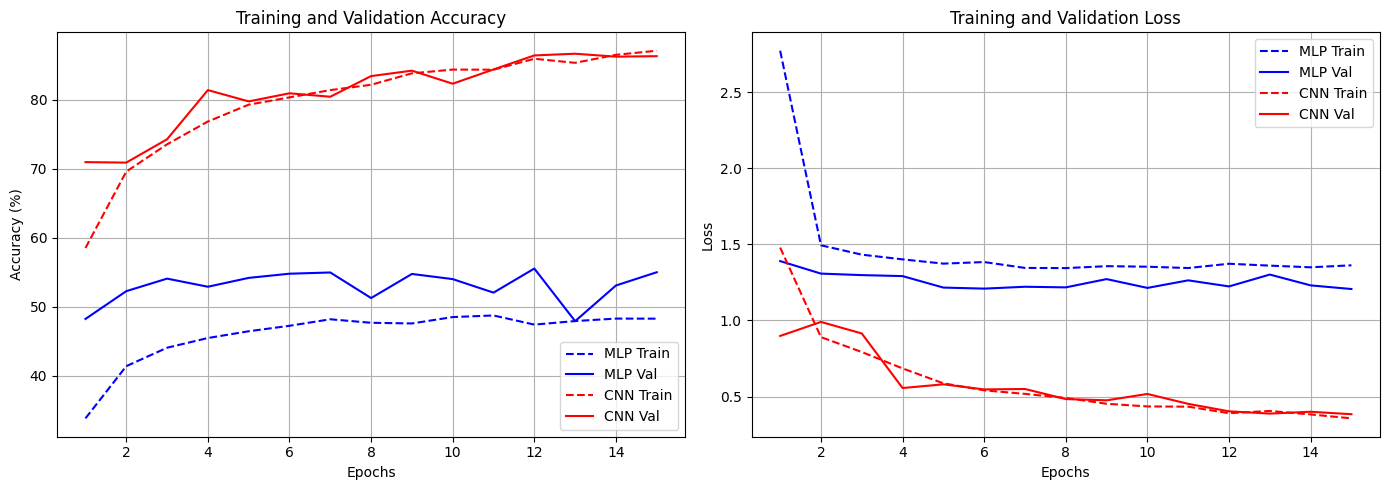

In [26]:
def plot_history(hist_mlp, hist_cnn):
    epochs = range(1, EPOCHS + 1)
    plt.figure(figsize=(14, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist_mlp['train_acc'], 'b--', label='MLP Train')
    plt.plot(epochs, hist_mlp['val_acc'], 'b-', label='MLP Val')
    plt.plot(epochs, hist_cnn['train_acc'], 'r--', label='CNN Train')
    plt.plot(epochs, hist_cnn['val_acc'], 'r-', label='CNN Val')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_mlp['train_loss'], 'b--', label='MLP Train')
    plt.plot(epochs, hist_mlp['val_loss'], 'b-', label='MLP Val')
    plt.plot(epochs, hist_cnn['train_loss'], 'r--', label='CNN Train')
    plt.plot(epochs, hist_cnn['val_loss'], 'r-', label='CNN Val')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history_mlp, history_cnn)

### 6.2  Confusion Matrix and Classification Report

Test Accuracy Comparison


,Model,Test Accuracy (%)
0,Baseline MLP,52.83
1,Custom CNN,85.83


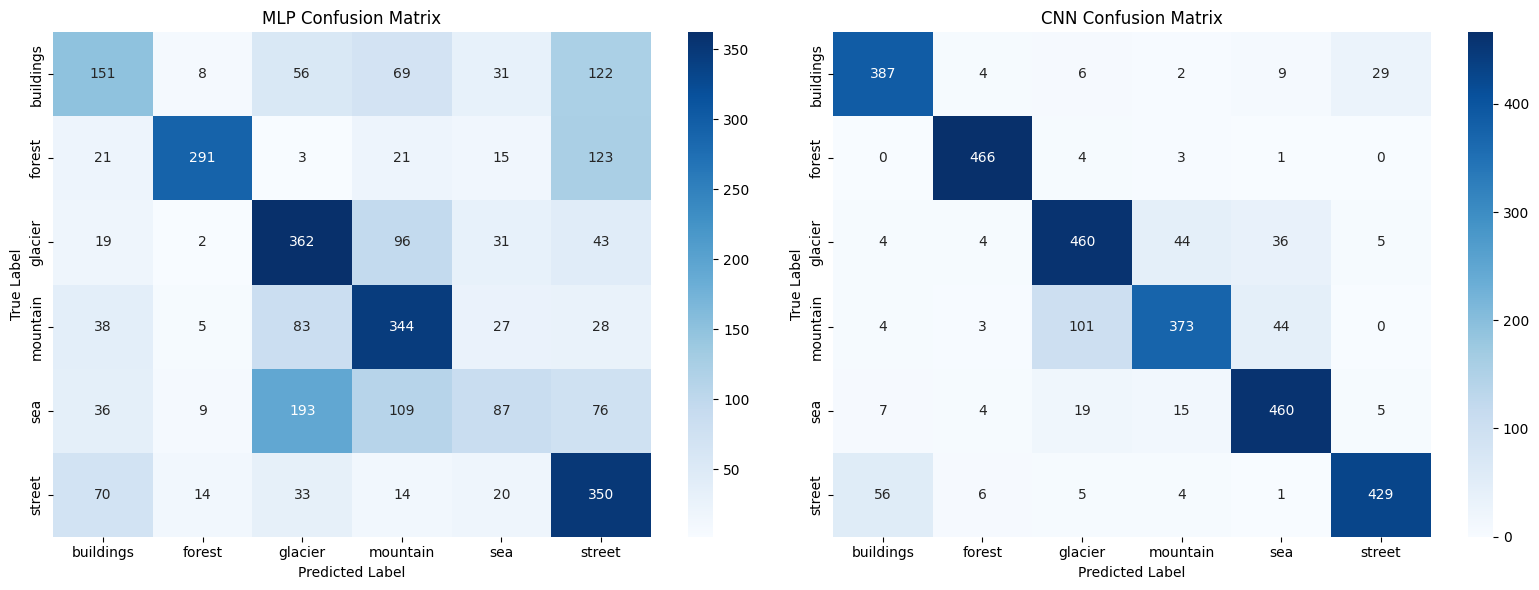

Classification Report - Baseline MLP
              precision    recall  f1-score   support

   buildings       0.45      0.35      0.39       437
      forest       0.88      0.61      0.72       474
     glacier       0.50      0.65      0.56       553
    mountain       0.53      0.66      0.58       525
         sea       0.41      0.17      0.24       510
      street       0.47      0.70      0.56       501

    accuracy                           0.53      3000
   macro avg       0.54      0.52      0.51      3000
weighted avg       0.54      0.53      0.51      3000

Classification Report - Custom CNN
              precision    recall  f1-score   support

   buildings       0.84      0.89      0.86       437
      forest       0.96      0.98      0.97       474
     glacier       0.77      0.83      0.80       553
    mountain       0.85      0.71      0.77       525
         sea       0.83      0.90      0.87       510
      street       0.92      0.86      0.89       501

    a

In [27]:
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean() * 100
    return y_true, y_pred, acc


mlp_true, mlp_pred, mlp_test_acc = collect_predictions(mlp_model, test_loader, DEVICE)
cnn_true, cnn_pred, cnn_test_acc = collect_predictions(cnn_model, test_loader, DEVICE)

comparison_df = pd.DataFrame(
    [
        {"Model": "Baseline MLP", "Test Accuracy (%)": round(mlp_test_acc, 2)},
        {"Model": "Custom CNN", "Test Accuracy (%)": round(cnn_test_acc, 2)},
    ]
)

print("Test Accuracy Comparison")
display(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, title, y_t, y_p in [
    (axes[0], "MLP Confusion Matrix", mlp_true, mlp_pred),
    (axes[1], "CNN Confusion Matrix", cnn_true, cnn_pred),
]:
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

print("Classification Report - Baseline MLP")
print(classification_report(mlp_true, mlp_pred, target_names=class_names))
print("Classification Report - Custom CNN")
print(classification_report(cnn_true, cnn_pred, target_names=class_names))


### 6.3 Sample Predictions (Correct & Incorrect)

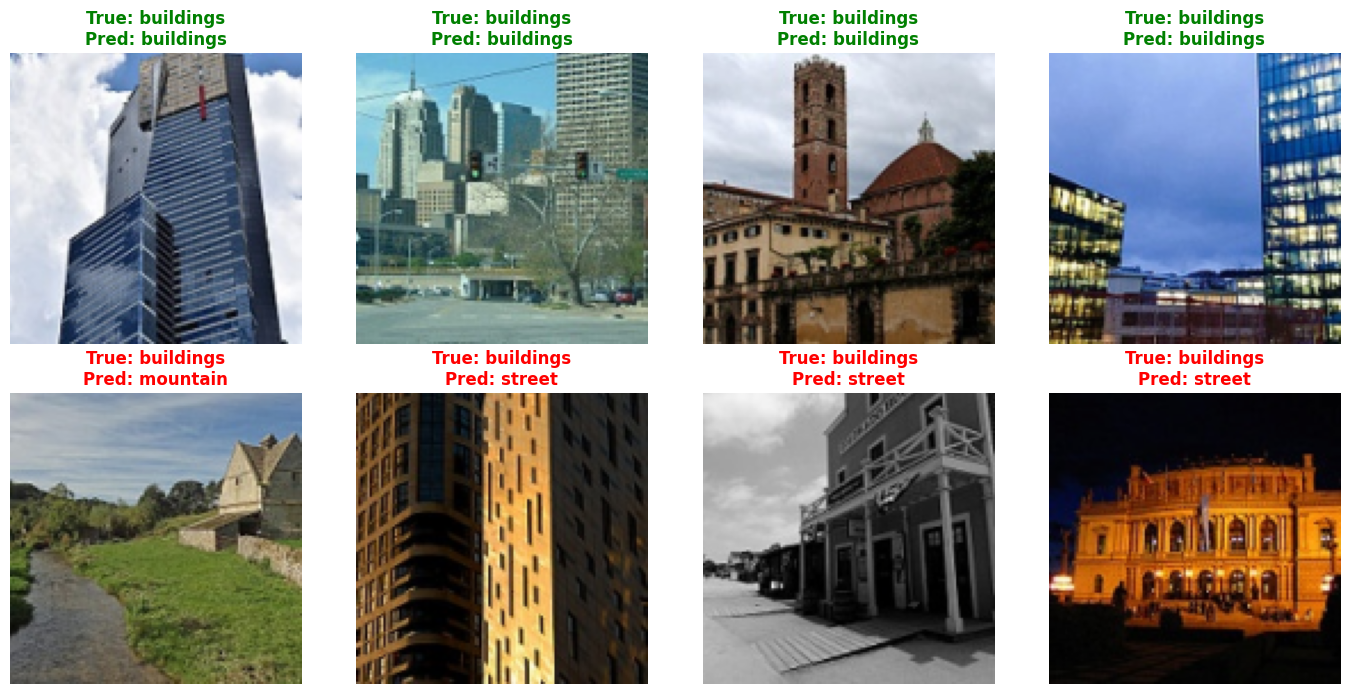

In [28]:
# 6.3 Sample Predictions (Correct & Incorrect)
cnn_model.eval()
correct_images, correct_labels, correct_preds = [], [], []
incorrect_images, incorrect_labels, incorrect_preds = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(labels)):
            if preds[i] == labels[i] and len(correct_images) < 4:
                correct_images.append(images[i].cpu())
                correct_labels.append(labels[i].cpu())
                correct_preds.append(preds[i].cpu())
            elif preds[i] != labels[i] and len(incorrect_images) < 4:
                incorrect_images.append(images[i].cpu())
                incorrect_labels.append(labels[i].cpu())
                incorrect_preds.append(preds[i].cpu())
                
        # Stop once we have 4 of each
        if len(correct_images) == 4 and len(incorrect_images) == 4:
            break

# Helper function to unnormalize and display the images
def imshow(img, title, color):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title, color=color, fontweight='bold')
    plt.axis('off')

plt.figure(figsize=(14, 7))
# Plot Correct Predictions (Top Row)
for i in range(4):
    plt.subplot(2, 4, i + 1)
    imshow(correct_images[i], f"True: {class_names[correct_labels[i]]}\nPred: {class_names[correct_preds[i]]}", "green")

# Plot Incorrect Predictions (Bottom Row)
for i in range(4):
    plt.subplot(2, 4, i + 5)
    imshow(incorrect_images[i], f"True: {class_names[incorrect_labels[i]]}\nPred: {class_names[incorrect_preds[i]]}", "red")

plt.tight_layout()
plt.show()

### 6.4 Visualization of Feature Maps

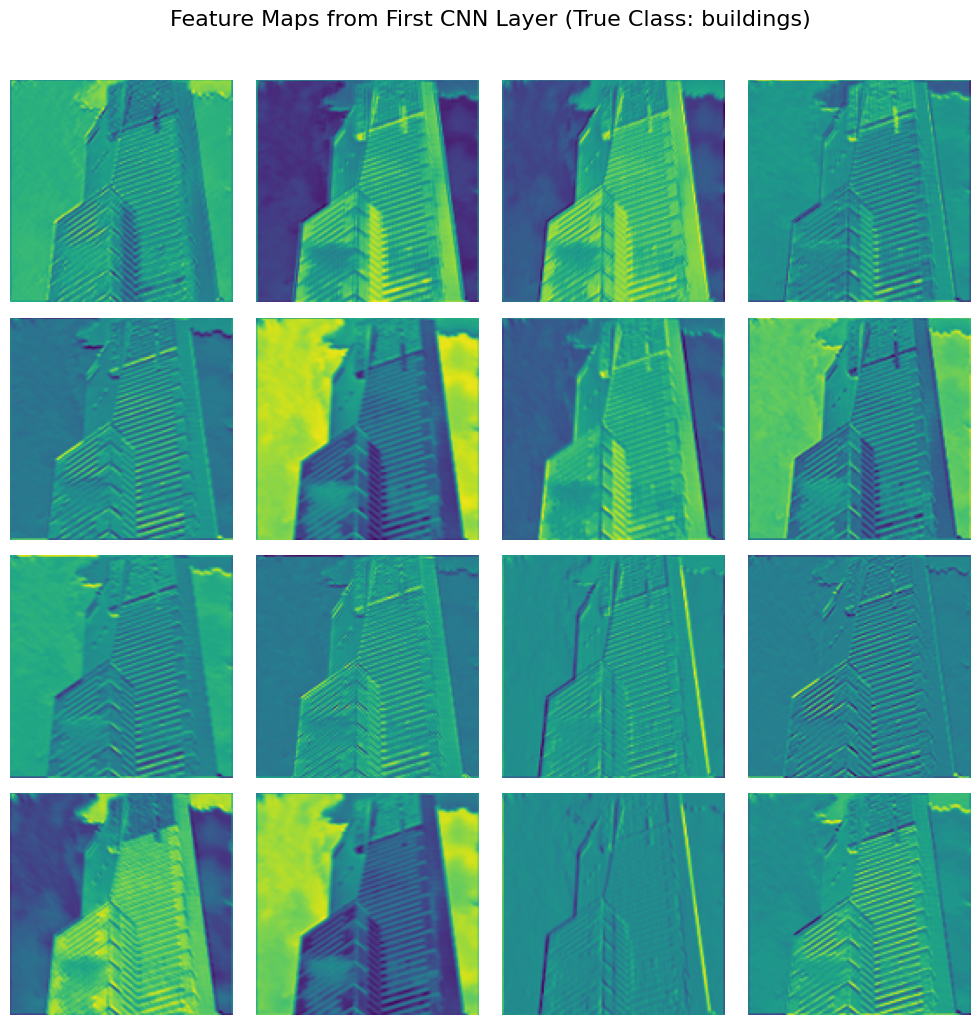

In [29]:
# 6.4 Visualization of Feature Maps
cnn_model.eval()

# Extract a single batch and take the first image
images, labels = next(iter(test_loader))
img = images[0].unsqueeze(0).to(DEVICE)

# Dynamically find the first Conv2d layer in your model
first_conv_layer = None
for module in cnn_model.modules():
    if isinstance(module, nn.Conv2d):
        first_conv_layer = module
        break

if first_conv_layer is not None:
    # Pass the image through just the first convolutional layer
    with torch.no_grad():
        feature_maps = first_conv_layer(img)
    
    feature_maps = feature_maps.squeeze(0).cpu().numpy()
    
    # Plot up to 16 feature maps from this layer in a 4x4 grid
    num_maps = min(16, feature_maps.shape[0])
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    
    for i, ax in enumerate(axes.flat):
        if i < num_maps:
            # Using 'viridis' for a high-contrast heatmap visualization
            ax.imshow(feature_maps[i], cmap='viridis')
        ax.axis('off')
        
    plt.suptitle(f"Feature Maps from First CNN Layer (True Class: {class_names[labels[0]]})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find a convolutional layer to visualize.")

### 6.5 Ablation Interpretation (Filters + Pooling)

In [31]:
if "comparison_df" in globals():
    mlp_acc = float(comparison_df.loc[comparison_df["Model"] == "Baseline MLP", "Test Accuracy (%)"].iloc[0])
    cnn_acc = float(comparison_df.loc[comparison_df["Model"] == "Custom CNN", "Test Accuracy (%)"].iloc[0])
    gain = cnn_acc - mlp_acc
    print(f"CNN improvement over MLP: {gain:.2f} percentage points")

if "ablation_df" in globals() and len(ablation_df) > 0:
    best_row = ablation_df.iloc[0]
    print("Best ablation setup:")
    print(
        f"- Config: {best_row['config']} | "
        f"Filters: {best_row['filters']} | Pooling: {best_row['pooling']} | "
        f"Best Val Acc: {best_row['best_val_acc']}%"
    )


CNN improvement over MLP: 33.00 percentage points
Best ablation setup:
- Config: MaxPool + Wider Filters | Filters: (32, 64, 128) | Pooling: max | Best Val Acc: 79.73%


## 7 Analysis and Evaluation


### 7.1 MLP vs CNN Performance
- Baseline MLP Model: The MLP model struggled with this dataset, converging to a validation accuracy of only **~55.01%** after 15 epochs. Both the training loss (1.36) and validation loss (1.20) increased. This confirms the theoretical limitation of MLPs on image data: flattening a 128x128x3 image into a 1D vector completely destroys the spatial features and local pixel relationships required to understand complex natural scenes.
- Custom CNN Model: The CNN drastically outperformed the baseline, achieving a validation accuracy of **86.32%** and a final test accuracy of **87%**. The training loss decreased smoothly to 0.35, and the validation loss had tracked closely at 0.38. The model generalizes incredibly well as we can see the extremely narrow gap between training and validation loss. The use of data augmentation, dropout, and normalization had successfully prevented overfitting.

### 7.2 Class-Wise Performance Analysis
Looking at the classification report, we can evaluate how the CNN has handled specific categories:
- **Forest (F1-Score: 0.97):** The model is highly confident and accurate at identifying forests. This is likely due to highly distinct color distributions (strong greens) and unique textural features that don't overlap with other classes.
- **Sea (0.87), Street (0.89), Buildings (0.86):** The model performs robustly across these categories. It successfully extracts distinct patterns like straight architectural edges for buildings/streets and flat blue textures for the sea.
- **Glacier (0.80) and Mountain (0.77):** These classes yielded the lowest precision and recall. This is a recognized and expected challenge within this dataset since snowy mountains and glaciers share highly similar visual characteristics . The model probably has confusion distinguishing between them.


## 8. Discussion

### 8.1 Why CNN Outperforms MLP
As observed in the results, the CNN significantly outperformed the baseline MLP (86% vs 54% validation accuracy). MLPs flatten the 2D image into a 1D vector, completely discarding the spatial structure and local pixel relationships. In contrast, CNNs maintain the 2D structure, allowing them to capture spatial hierarchies (edges, textures, objects) regardless of where they appear in the image. This weight-sharing and spatial awareness make CNNs far more robust and parameter-efficient for computer vision tasks.

### 8.2 The Role of Convolution and Pooling
- **Convolutional Layers:** These act as spatial feature extractors. By sliding learnable filters (kernels) over the image, they detect local patterns. Early layers typically learn simple features like edges and colors, while deeper layers combine these to recognize complex semantic shapes (like windows in buildings or the texture of trees). 
- **Pooling Layers (e.g., MaxPooling):** Pooling reduces the spatial dimensions (width and height) of the feature maps. This decreases the computational load and the number of parameters, mitigating overfitting. Crucially, pooling provides *translation invariance*, meaning the network can recognize a feature even if it slightly shifts its position in the frame.

### 8.3 Observations on Bias-Variance & Overfitting
The baseline MLP exhibited high bias (underfitting) regarding spatial features, failing to learn the visual complexity of the dataset. If made deeper, an MLP would quickly suffer from high variance (overfitting) due to the massive number of dense parameters. The CNN, however, paired with data augmentation and dropout, achieved a strong balance. The narrow gap between train and validation loss in the CNN curves indicates excellent generalization and effectively controlled overfitting.

## 9. Conclusion
- The custom CNN significantly outperformed the dense MLP, proving that preserving 2D spatial relationships is crucial for successful image classification.
- Convolutional layers successfully extracted hierarchical visual features (like the distinct textures of forests and flat surfaces of seas), while pooling layers reduced dimensionality and even provided spatial invariance.
- Regularization techniques, particularly Data Augmentation and Dropout, were highly effective in preventing the CNN from memorizing the training data, leading to a strong test accuracy of 87%.
- The confusion matrix reveals that the model struggles most with visually similar classes, such as Mountains and Glaciers, highlighting the difficulty of differentiating textures without broader environmental context.
